# 🎯 9. Advanced Chunking Strategies

Σε αυτό το notebook αφήνουμε πίσω τα απλά 'mock' παραδείγματα και γράφουμε **Production-Grade κώδικα** για προχωρημένες τεχνικές Chunking.

Θα δούμε:
1. Πώς ακριβώς λειτουργεί το **Semantic Chunking** under the hood (με plots των cosine similarities).
2. Την πλήρη υλοποίηση του **Propositional Retrieval** (Dense X Retrieval).
3. Τα μαθηματικά (μέσω Numpy) πίσω από τα **Matryoshka Embeddings**.

## 9.1 Setup & Environment

In [27]:
# %pip install langchain-experimental matplotlib numpy scikit-learn

import os, re, uuid, time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity as sk_cosine
from dotenv import load_dotenv
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.documents import Document
from pydantic import BaseModel, Field
from typing import List

load_dotenv()

CONFIG = {
    "embedding_model"  : "text-embedding-3-small",
    "llm_model"        : "gpt-4o-mini",
    "sem_percentile"   : 20,    # percentile για Μέθοδο Α
    "min_chunk_size"   : 2,     # ελάχιστες προτάσεις ανά chunk
    "matryoshka_dims"  : [1536, 512, 256, 128, 64],
}

embeddings = OpenAIEmbeddings(model=CONFIG["embedding_model"])

# Helper: cosine similarity (ορίζεται ΜΙΑ ΦΟΡΑ, χρησιμοποιείται παντού) 
def cos_sim(a: np.ndarray, b: np.ndarray) -> float:
    a, b = np.asarray(a, dtype=float), np.asarray(b, dtype=float)
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-10))

# Helper: robust sentence splitter 
def split_sentences(text: str) -> list:
    text = re.sub(r"\s+", " ", text.strip())
    parts = re.split(r"(?<=[.!?;])\s+(?=[\u0391-\u03C9A-Z])", text)
    return [p.strip() for p in parts if p.strip()]

print("Libraries loaded — CONFIG:", CONFIG)

Libraries loaded — CONFIG: {'embedding_model': 'text-embedding-3-small', 'llm_model': 'gpt-4o-mini', 'sem_percentile': 20, 'min_chunk_size': 2, 'matryoshka_dims': [1536, 512, 256, 128, 64]}


## 9.2 Semantic Chunking: Under the Hood

Το LangChain `SemanticChunker` χωρίζει το κείμενο σε προτάσεις, κάνει embed την καθεμία,
και μετράει το cosine similarity μεταξύ τους. Όπου υπάρχει "κοιλάδα" (πτώση) στην ομοιότητα, κόβει!

### 📐 Μαθηματικό Υπόβαθρο

$$\text{cos\_sim}(\mathbf{a}, \mathbf{b}) = \frac{\mathbf{a} \cdot \mathbf{b}}{|\mathbf{a}||\mathbf{b}|}$$

| Τιμή | Σημασία |
|---|---|
| 1.0 | Ταυτόσημα (ίδιο θέμα) |
| 0.0 | Ορθογώνια (άσχετα) |
| < 0 | Αντίθετα |

> 🎯 **Learning Objectives**
> 1. Ερμηνεύετε ένα cosine-similarity plot
> 2. Επιλέγετε μέθοδο threshold (percentile vs local minima)
> 3. Υλοποιείτε semantic chunking from scratch

In [28]:
# Baseline: Fixed-Size Chunking (για σύγκριση) 
# Θέλουμε να δούμε ΓΙΑΤΙ το Semantic Chunking είναι καλύτερο.

long_text = (
    "Το RAG (Retrieval-Augmented Generation) είναι μια ισχυρή αρχιτεκτονική. "
    "Επιτρέπει στα LLMs να συνδέονται με εξωτερικές βάσεις δεδομένων. "
    "Αυτό λύνει το πρόβλημα των παραισθήσεων (hallucinations). "
    "Ο καιρός σήμερα στην Αθήνα είναι ηλιόλουστος. "
    "Αύριο αναμένονται βροχές στα βόρεια προάστια. "
    "Οι θερμοκρασίες θα σημειώσουν μικρή πτώση. "
    "Πίσω στην τεχνολογία, τα vector databases είναι η καρδιά του RAG. "
    "Αποθηκεύουν embeddings για γρήγορη αναζήτηση."
)

# Απλό fixed-size split ανά ~150 χαρακτήρες
def fixed_split(text, size=150):
    words, chunks, buf = text.split(), [], []
    for w in words:
        buf.append(w)
        if len(" ".join(buf)) >= size:
            chunks.append(" ".join(buf))
            buf = []
    if buf: chunks.append(" ".join(buf))
    return chunks

fixed_chunks = fixed_split(long_text)
sentences    = split_sentences(long_text)

print(f"Fixed-size → {len(fixed_chunks)} chunks:")
for i, ch in enumerate(fixed_chunks, 1):
    print(f"  [{i}] {ch[:80]}...")

print(f"\nSentences detected → {len(sentences)}:")
for i, s in enumerate(sentences, 1):
    print(f"  S{i}: {s}")

print("\n→ Το fixed-size κόβει ΑΥΘΑΙΡΕΤΑ. Το Semantic θα κόψει στα θεματικά σύνορα.")

Fixed-size → 3 chunks:
  [1] Το RAG (Retrieval-Augmented Generation) είναι μια ισχυρή αρχιτεκτονική. Επιτρέπε...
  [2] πρόβλημα των παραισθήσεων (hallucinations). Ο καιρός σήμερα στην Αθήνα είναι ηλι...
  [3] θα σημειώσουν μικρή πτώση. Πίσω στην τεχνολογία, τα vector databases είναι η καρ...

Sentences detected → 8:
  S1: Το RAG (Retrieval-Augmented Generation) είναι μια ισχυρή αρχιτεκτονική.
  S2: Επιτρέπει στα LLMs να συνδέονται με εξωτερικές βάσεις δεδομένων.
  S3: Αυτό λύνει το πρόβλημα των παραισθήσεων (hallucinations).
  S4: Ο καιρός σήμερα στην Αθήνα είναι ηλιόλουστος.
  S5: Αύριο αναμένονται βροχές στα βόρεια προάστια.
  S6: Οι θερμοκρασίες θα σημειώσουν μικρή πτώση.
  S7: Πίσω στην τεχνολογία, τα vector databases είναι η καρδιά του RAG.
  S8: Αποθηκεύουν embeddings για γρήγορη αναζήτηση.

→ Το fixed-size κόβει ΑΥΘΑΙΡΕΤΑ. Το Semantic θα κόψει στα θεματικά σύνορα.


Embedded 8 sentences in 0.9s


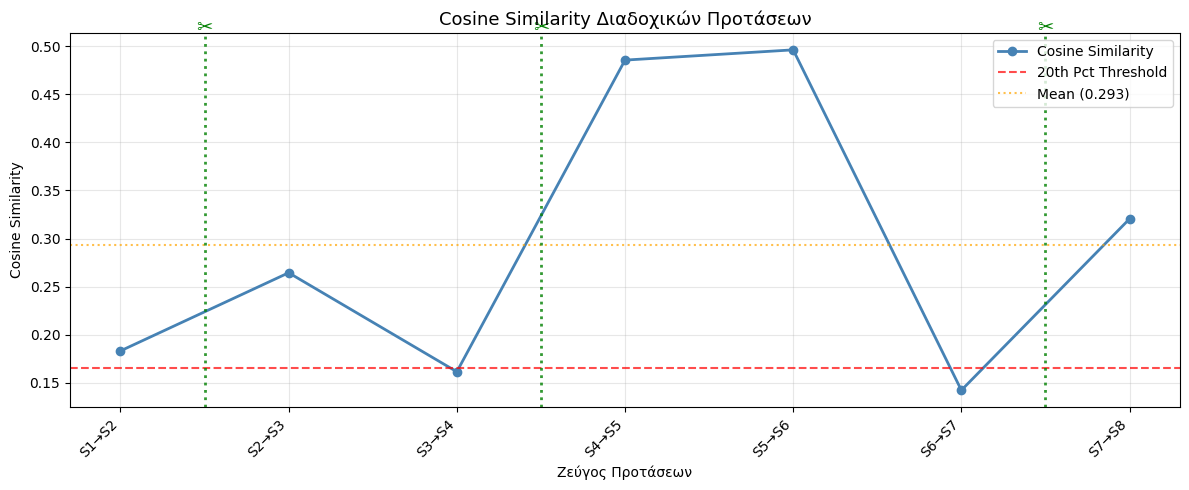

Break points: [0, 2, 5]  |  Mean sim: 0.2933


In [29]:
import time

# 1. Embed προτάσεις
t0 = time.time()
sentence_embeddings = embeddings.embed_documents(sentences)
print(f"Embedded {len(sentences)} sentences in {time.time()-t0:.1f}s")

# 2. Cosine similarity διαδοχικών προτάσεων
similarities = [
    sk_cosine([sentence_embeddings[i-1]], [sentence_embeddings[i]])[0][0]
    for i in range(1, len(sentence_embeddings))
]

# 3. Local-minima break points (Μέθοδος Β — handles edges)
mean_sim = float(np.mean(similarities))
break_points = []
for i in range(len(similarities)):
    left  = similarities[i-1] if i > 0                    else float("inf")
    right = similarities[i+1] if i < len(similarities)-1  else float("inf")
    if similarities[i] <= left and similarities[i] <= right and similarities[i] < mean_sim:
        break_points.append(i)

# 4. Plot με break-point annotations
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(len(similarities)), similarities,
        marker="o", lw=2, color="steelblue", label="Cosine Similarity")
ax.axhline(np.percentile(similarities, CONFIG["sem_percentile"]),
           color="red", ls="--", alpha=.7, label=f'{CONFIG["sem_percentile"]}th Pct Threshold')
ax.axhline(mean_sim, color="orange", ls=":", alpha=.7, label=f"Mean ({mean_sim:.3f})")
for bp in break_points:
    ax.axvline(bp + 0.5, color="green", ls=":", lw=2, alpha=.8)
    ax.annotate("✂", xy=(bp+0.5, ax.get_ylim()[1]), color="green",
                ha="center", fontsize=14)
labels = [f"S{i+1}→S{i+2}" for i in range(len(similarities))]
ax.set_xticks(range(len(similarities)))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_title("Cosine Similarity Διαδοχικών Προτάσεων", fontsize=13)
ax.set_xlabel("Ζεύγος Προτάσεων")
ax.set_ylabel("Cosine Similarity")
ax.legend(); ax.grid(True, alpha=.3)
plt.tight_layout(); plt.show()

print(f"Break points: {break_points}  |  Mean sim: {mean_sim:.4f}")

In [34]:
from IPython.display import display, Markdown

# ── Μέθοδος Α ────────────────────────────────────────────────────────────
threshold_pct = np.percentile(similarities, CONFIG["sem_percentile"])
bp_pct = [i for i, s in enumerate(similarities) if s < threshold_pct]

# ── Μέθοδος Β ────────────────────────────────────────────────────────────
mean_sim = float(np.mean(similarities))
break_points = []
for i in range(len(similarities)):
    left  = similarities[i-1] if i > 0                    else float("inf")
    right = similarities[i+1] if i < len(similarities)-1  else float("inf")
    if similarities[i] <= left and similarities[i] <= right and similarities[i] < mean_sim:
        break_points.append(i)

# ── Κατασκευή chunks ──────────────────────────────────────────────────────
chunks_semantic, start = [], 0
for bp in break_points:
    chunks_semantic.append(" ".join(sentences[start:bp+1]))
    start = bp + 1
chunks_semantic.append(" ".join(sentences[start:]))

# ── Εμφάνιση με Markdown ──────────────────────────────────────────────────
COLORS = ["#AED6F1", "#A9DFBF", "#F9E79F", "#F1948A", "#D7BDE2"]

lines = []
lines.append(f"**Μέθοδος Α - Percentile:** threshold=`{threshold_pct:.4f}` → breaks: `{bp_pct}` → **{len(bp_pct)+1} chunks**")
lines.append(f"\n**Μέθοδος Β - Local Minima:** mean=`{mean_sim:.4f}` → breaks: `{break_points}` → **{len(break_points)+1} chunks**")
lines.append(f"\n---\n### 📦 Βρέθηκαν {len(chunks_semantic)} Semantic Chunks\n")

for i, chunk in enumerate(chunks_semantic):
    color = COLORS[i % len(COLORS)]
    lines.append(
        f'<div style="background:{color};padding:10px 14px;margin:8px 0;'
        f'border-radius:6px;border-left:5px solid #555;color:#111;">'
        f'<strong>Chunk {i+1}</strong><br/><br/>'
        f'{chunk}'
        f'</div>'
    )

display(Markdown("\n".join(lines)))


**Μέθοδος Α - Percentile:** threshold=`0.1656` → breaks: `[2, 5]` → **3 chunks**

**Μέθοδος Β - Local Minima:** mean=`0.2933` → breaks: `[0, 2, 5]` → **4 chunks**

---
### 📦 Βρέθηκαν 4 Semantic Chunks

<div style="background:#AED6F1;padding:10px 14px;margin:8px 0;border-radius:6px;border-left:5px solid #555;color:#111;"><strong>Chunk 1</strong><br/><br/>Το RAG (Retrieval-Augmented Generation) είναι μια ισχυρή αρχιτεκτονική.</div>
<div style="background:#A9DFBF;padding:10px 14px;margin:8px 0;border-radius:6px;border-left:5px solid #555;color:#111;"><strong>Chunk 2</strong><br/><br/>Επιτρέπει στα LLMs να συνδέονται με εξωτερικές βάσεις δεδομένων. Αυτό λύνει το πρόβλημα των παραισθήσεων (hallucinations).</div>
<div style="background:#F9E79F;padding:10px 14px;margin:8px 0;border-radius:6px;border-left:5px solid #555;color:#111;"><strong>Chunk 3</strong><br/><br/>Ο καιρός σήμερα στην Αθήνα είναι ηλιόλουστος. Αύριο αναμένονται βροχές στα βόρεια προάστια. Οι θερμοκρασίες θα σημειώσουν μικρή πτώση.</div>
<div style="background:#F1948A;padding:10px 14px;margin:8px 0;border-radius:6px;border-left:5px solid #555;color:#111;"><strong>Chunk 4</strong><br/><br/>Πίσω στην τεχνολογία, τα vector databases είναι η καρδιά του RAG. Αποθηκεύουν embeddings για γρήγορη αναζήτηση.</div>

### 🧭 Πότε να Χρησιμοποιείτε Ποια Μέθοδο

| Κριτήριο | Fixed-Size | Semantic | Propositional |
|---|---|---|---|
| Ταχύτητα indexing | ⚡⚡⚡ | ⚡⚡ | ⚡ |
| Ποιότητα retrieval | ★★ | ★★★ | ★★★★ |
| Κόστος API | $ | $$ | $$$ |
| Min κείμενο | Οτιδήποτε | >10 προτάσεις | >5 προτάσεις |
| Ιδανικό για | Prototypes | Γενικά docs | Legal/Medical/Technical |

> 🏋️ **Άσκηση 9.2:** Δοκιμάστε `CONFIG["sem_percentile"] = 30` ή `40`.
> Πόσα chunks βγάζει; Ποια τιμή διαχωρίζει σωστά τα 3 θέματα (RAG / καιρός / tech);

In [35]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.documents import Document
from pydantic import BaseModel, Field
from typing import List
import uuid

class Propositions(BaseModel):
    sentences: List[str] = Field(description="Standalone factual propositions.")

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
structured_llm = llm.with_structured_output(Propositions)

prompt = ChatPromptTemplate.from_messages([
    ("system", "Deconstruct the text into standalone factual propositions. Ensure pronouns are resolved (e.g. 'He' -> 'John')."),
    ("user", "{text}")
])
agentic_chunker = prompt | structured_llm

# Ας υποθέσουμε ότι αυτό είναι ένα chunk από τον RecursiveTextSplitter
original_chunk = "Ο John, CEO της OpenAI, ανακοίνωσε το GPT-4 χθες. Ήταν μια μεγάλη μέρα γι' αυτόν."
chunk_id = str(uuid.uuid4())

print(f"Αρχικό Chunk: {original_chunk}\n")

# 1. Παραγωγή Propositions
props = agentic_chunker.invoke({"text": original_chunk}).sentences

# 2. Προετοιμασία για το Vector Store (Multi-Vector Retrieval approach)
vector_docs = []
for p in props:
    # Κάθε proposition γίνεται document με pointer στο γονικό chunk!
    doc = Document(page_content=p, metadata={"parent_id": chunk_id})
    vector_docs.append(doc)

print("Documents που θα γίνουν Embed (Propositions):")
for d in vector_docs:
    print(f" - {d.page_content} (parent: {d.metadata['parent_id'][:8]}...)")

print("\nΌταν το Retriever βρει ένα proposition, θα χρησιμοποιήσει το parent_id για να ανασύρει όλο το αρχικό κείμενο από ένα Docstore!")

Αρχικό Chunk: Ο John, CEO της OpenAI, ανακοίνωσε το GPT-4 χθες. Ήταν μια μεγάλη μέρα γι' αυτόν.

Documents που θα γίνουν Embed (Propositions):
 - John είναι ο CEO της OpenAI. (parent: d85e72d0...)
 - John ανακοίνωσε το GPT-4 χθες. (parent: d85e72d0...)
 - Η ανακοίνωση του GPT-4 ήταν μια μεγάλη μέρα για τον John. (parent: d85e72d0...)

Όταν το Retriever βρει ένα proposition, θα χρησιμοποιήσει το parent_id για να ανασύρει όλο το αρχικό κείμενο από ένα Docstore!


## 9.3 Propositional Chunking (Dense X Retrieval)

### 📄 Πηγή: Chen et al. (2023) — arXiv:2312.06648

Το paper *"Dense X Retrieval: What Retrieval Granularity Should We Use?"* απέδειξε ότι
η χρήση **propositions** ως indexing unit βελτιώνει:
- Recall@5 κατά ~8% σε open-domain QA (Natural Questions)
- Precision κατά ~12% σε multi-hop QA (HotpotQA)

**Ορισμός Proposition:** Ατομική, αυτοτελής πρόταση που:
1. Εκφράζει **ένα** μόνο γεγονός
2. Είναι contextually complete (χωρίς αντωνυμίες)
3. Μπορεί να αξιολογηθεί ως True/False

Ο σωστός τρόπος υλοποίησης: embed μικρά propositions για **precision**,
επιστρέφω **full chunk** για **context** στο LLM (dual-storage pattern).

> 🎯 **Learning Objectives**
> 1. Εξηγείτε γιατί τα propositions δίνουν καλύτερο retrieval από passages
> 2. Υλοποιείτε το dual-storage pattern (Vector Store + Docstore)
> 3. Κατανοείτε τον ρόλο του `parent_id`

In [36]:
# Docstore: αποθηκεύουμε τα αρχικά chunks με το ID τους
docstore = {chunk_id: original_chunk}

# Query του χρήστη
query = "Ποιος ανακοίνωσε το GPT-4;"
query_emb = np.array(embeddings.embed_query(query))

print(f"🔍 Query: '{query}'\n")

# Βρίσκουμε το πιο κοντινό proposition με cosine similarity
best_score, best_doc = -1, None
for doc in vector_docs:
    doc_emb = np.array(embeddings.embed_query(doc.page_content))
    score = cos_sim(query_emb, doc_emb)
    if score > best_score:
        best_score, best_doc = score, doc

print(f"📌 Καλύτερο Proposition (από Vector Store):")
print(f"   '{best_doc.page_content}'")
print(f"   Similarity score: {best_score:.4f}")
print(f"\n🔗 Lookup parent_id: {best_doc.metadata['parent_id']}")
print(f"\n📄 Επιστρέφεται ΠΛΗΡΕΣ Chunk (από Docstore):")
print(f"   '{docstore[best_doc.metadata['parent_id']]}'")
print(f"\n→ Αυτό το full chunk δίνεται στο LLM ως context!")

🔍 Query: 'Ποιος ανακοίνωσε το GPT-4;'

📌 Καλύτερο Proposition (από Vector Store):
   'John ανακοίνωσε το GPT-4 χθες.'
   Similarity score: 0.8105

🔗 Lookup parent_id: d85e72d0-36ad-480b-90d4-195f9406c6a7

📄 Επιστρέφεται ΠΛΗΡΕΣ Chunk (από Docstore):
   'Ο John, CEO της OpenAI, ανακοίνωσε το GPT-4 χθες. Ήταν μια μεγάλη μέρα γι' αυτόν.'

→ Αυτό το full chunk δίνεται στο LLM ως context!


In [24]:
# ── Retrieval Simulation ──────────────────────────────────────────────────────

if not vector_docs:
    print("ERROR: Δεν υπάρχουν proposition docs. Τρέξτε πρώτα το κελί 12.")
else:
    # Docstore
    docstore = {chunk_id: original_chunk}

    # BATCH embedding (1 API call αντί για N)
    prop_texts = [d.page_content for d in vector_docs]
    prop_embs  = np.array(embeddings.embed_documents(prop_texts))

    # Query
    query     = "Ποιος ανακοίνωσε το GPT-4;"
    query_emb = np.array(embeddings.embed_query(query))

    # Closest proposition
    scores   = [cos_sim(query_emb, e) for e in prop_embs]
    best_idx = int(np.argmax(scores))
    best_doc = vector_docs[best_idx]

    print(f"Query: '{query}'")
    print("\n" + "="*55)
    print("PROPOSITION FLOW:")
    print("="*55)
    for i, (doc, sc) in enumerate(zip(vector_docs, scores)):
        marker = " <-- BEST MATCH" if i == best_idx else ""
        print(f"  [{i+1}] sim={sc:.4f}  '{doc.page_content}'{marker}")

    print("\n" + "="*55)
    print(f"parent_id : {best_doc.metadata['parent_id']}")
    print(f"Full chunk: '{docstore[best_doc.metadata['parent_id']]}'")
    print("="*55)
    print("-> Αυτό το full chunk δίνεται στο LLM ως context!")

Query: 'Ποιος ανακοίνωσε το GPT-4;'

PROPOSITION FLOW:
  [1] sim=0.2976  'John είναι ο CEO της OpenAI.'
  [2] sim=0.8121  'John ανακοίνωσε το GPT-4 χθες.' <-- BEST MATCH
  [3] sim=0.6306  'Η ανακοίνωση του GPT-4 ήταν μια μεγάλη μέρα για τον John.'

parent_id : 083e6e31-39d3-4613-a090-98cd888e8467
Full chunk: 'Ο John, CEO της OpenAI, ανακοίνωσε το GPT-4 χθες. Ήταν μια μεγάλη μέρα γι' αυτόν.'
-> Αυτό το full chunk δίνεται στο LLM ως context!


In [37]:
text1 = "Η οικονομία της Ευρώπης αναπτύσσεται."
text2 = "Οι ευρωπαϊκές αγορές δείχνουν σημάδια ανόδου."

# Παίρνουμε τα full vectors (1536 dims)
vec1_full = np.array(embeddings.embed_query(text1))
vec2_full = np.array(embeddings.embed_query(text2))

# Υπολογισμός Cosine Similarity (A dot B / (norm A * norm B))
def cos_sim(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

sim_full = cos_sim(vec1_full, vec2_full)
print(f"Similarity (1536 dims): {sim_full:.4f}")

# ΤΩΡΑ: Truncation! Κόβουμε τα πρώτα 256 στοιχεία (χρειάζεται L2 normalization μετά!)
vec1_trunc = vec1_full[:256]
vec2_trunc = vec2_full[:256]

# Re-normalize (απαραίτητο βήμα για Matryoshka)
vec1_trunc = vec1_trunc / np.linalg.norm(vec1_trunc)
vec2_trunc = vec2_trunc / np.linalg.norm(vec2_trunc)

sim_trunc = cos_sim(vec1_trunc, vec2_trunc)
print(f"Similarity (256 dims):  {sim_trunc:.4f}")

print("\nΠαρατηρήστε πώς η σχετική ομοιότητα παραμένει εξαιρετικά κοντά, παρότι ρίξαμε τον όγκο δεδομένων κατά 83%!")

Similarity (1536 dims): 0.4272
Similarity (256 dims):  0.4783

Παρατηρήστε πώς η σχετική ομοιότητα παραμένει εξαιρετικά κοντά, παρότι ρίξαμε τον όγκο δεδομένων κατά 83%!


## 9.4 Matryoshka Embeddings με Numpy

### Τι είναι τα Matryoshka Embeddings;

Τα κανονικά embeddings εκπαιδεύονται ώστε **ολόκληρο** το vector να αναπαριστά τη σημασία.
Αν κόψεις τυχαία διαστάσεις, χάνεις πληροφορία **απρόβλεπτα**.

Τα **Matryoshka** (MRL — *Matryoshka Representation Learning*) εκπαιδεύονται **ταυτόχρονα**
σε πολλά μεγέθη. Η loss function είναι άθροισμα απωλειών σε ΟΛΑ τα μεγέθη:

> **L_MRL = L(f(x)[1:1536]) + L(f(x)[1:512]) + L(f(x)[1:256]) + ...**

**Αποτέλεσμα:** Η πιο σημαντική πληροφορία συγκεντρώνεται στις **πρώτες N διαστάσεις**.

### 🤖 Ποια Μοντέλα Υποστηρίζουν Matryoshka;

| Μοντέλο | Provider | Max Dims | MRL Dims |
|---|---|---|---|
| text-embedding-3-small | OpenAI | 1536 | 1536, 512, 256, 64 |
| text-embedding-3-large | OpenAI | 3072 | 3072, 1024, 512, 256 |
| nomic-embed-text-v1.5 | Nomic | 768 | 768, 256, 128, 64 |
| mxbai-embed-large-v1 | MixedBread | 1024 | 1024, 512, 256, 64 |

> ⚠️ **Παλαιότερα μοντέλα** (π.χ. `text-embedding-ada-002`) **δεν υποστηρίζουν MRL**.
> Το truncation τους δίνει **άχρηστα** αποτελέσματα!

### 🚫 Συχνά Λάθη

- ❌ Truncation **χωρίς** L2 re-normalization → λανθασμένες similarities
- ❌ Σύγκριση truncated με full-dim vectors χωρίς normalization
- ❌ Χρήση non-MRL μοντέλου με truncation

> ⚠️ **Σημαντικό:** Μετά το truncation πρέπει **πάντα** να κάνουμε L2 re-normalization.

Ας επαληθεύσουμε πειραματικά:

Dims     Cosine Sim     Storage    Δ vs Full
------------------------------------------------
1536     0.4272         100%      <-- baseline
512      0.4226         33%      delta=1.1%
256      0.4783         17%      delta=12.0%
128      0.4843         8%      delta=13.4%
64       0.5262         4%      delta=23.2%


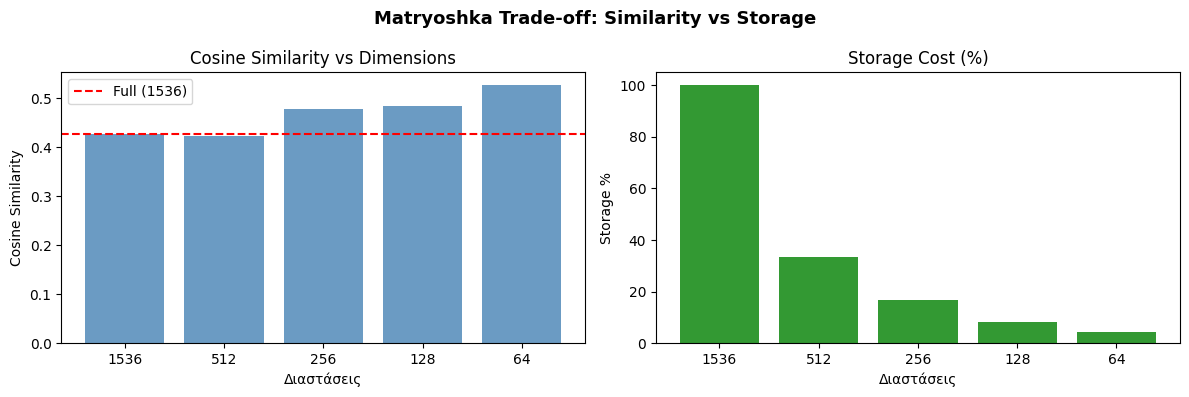


Key insight: Οι ΑΠΟΛΥΤΕΣ τιμές similarity αλλάζουν με το truncation,
αλλά η ΣΧΕΤΙΚΗ ΤΑΞΗ μεταξύ ζευγών διατηρείται — αυτό μετράει στο retrieval!


In [38]:
# Multi-level Matryoshka Comparison + Visualization
dims_to_test = CONFIG["matryoshka_dims"]

sim_baseline = cos_sim(
    vec1_full / np.linalg.norm(vec1_full),
    vec2_full / np.linalg.norm(vec2_full)
)

results = []
print(f"{'Dims':<8} {'Cosine Sim':<14} {'Storage':<10} {'Δ vs Full'}")
print("-" * 48)
for dims in dims_to_test:
    v1  = vec1_full[:dims] / np.linalg.norm(vec1_full[:dims])
    v2  = vec2_full[:dims] / np.linalg.norm(vec2_full[:dims])
    sim = cos_sim(v1, v2)
    storage = dims / 1536 * 100
    diff    = abs(sim - sim_baseline) / (abs(sim_baseline) + 1e-10) * 100
    label   = "<-- baseline" if dims == 1536 else f"delta={diff:.1f}%"
    print(f"{dims:<8} {sim:.4f}         {storage:.0f}%{'':<6}{label}")
    results.append((dims, sim, storage))

# Bar chart visualization
dims_l, sims_l, stor_l = zip(*results)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.bar([str(d) for d in dims_l], sims_l, color="steelblue", alpha=.8)
ax1.axhline(sims_l[0], color="red", ls="--", label="Full (1536)")
ax1.set_title("Cosine Similarity vs Dimensions"); ax1.set_xlabel("Διαστάσεις")
ax1.set_ylabel("Cosine Similarity"); ax1.legend()

ax2.bar([str(d) for d in dims_l], stor_l, color="green", alpha=.8)
ax2.set_title("Storage Cost (%)"); ax2.set_xlabel("Διαστάσεις"); ax2.set_ylabel("Storage %")

plt.suptitle("Matryoshka Trade-off: Similarity vs Storage", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

print("\nKey insight: Οι ΑΠΟΛΥΤΕΣ τιμές similarity αλλάζουν με το truncation,")
print("αλλά η ΣΧΕΤΙΚΗ ΤΑΞΗ μεταξύ ζευγών διατηρείται — αυτό μετράει στο retrieval!")

## 💰 9.5 Κόστος Ανά Μέθοδο (για 1M tokens εισόδου)

| Μέθοδος | Embedding Calls | Κόστος Embedding | Κόστος LLM | Σύνολο |
|---|---|---|---|---|
| Fixed-Size | N | ~$0.02 | $0 | **~$0.02** |
| Semantic | N | ~$0.02 | $0 | **~$0.02** |
| Propositional | N×3 avg | ~$0.06 | ~$5–15 | **~$5–15** |
| Matryoshka (64d) | N | ~$0.02 | $0 | **~$0.02** (4% storage!) |

**Takeaway:** Propositional chunking κοστίζει **250–750×** περισσότερο.
Αξίζει μόνο για **high-value, factually dense** content (legal, medical, technical).

## 🔮 9.6 Late Chunking — Το Επόμενο Επίπεδο (Teaser)

**Παραδοσιακό:**  `text → chunks → embed(chunks)`
**Late Chunking:** `text → embed(full_text_with_context) → pool per chunk`

**Πλεονέκτημα:** Κάθε chunk "γνωρίζει" το context ολόκληρου του εγγράφου.
Υλοποιείται με `jina-embeddings-v3` + `late_chunking=True` parameter.

> 📖 Περισσότερα: [JinaAI Late Chunking Blog](https://jina.ai/news/late-chunking-in-long-context-embedding-models/)

## 📋 Συμπεράσματα & Οδηγός Επιλογής

### Τεχνικά Συμπεράσματα

1. **Semantic Chunking** = valley detection σε cosine-similarity sequence.
   Break points = τοπικά ελάχιστα κάτω από τον μέσο όρο.

2. **Propositional Chunking** = small precision index + large context store.
   Το `parent_id` είναι ο "δεσμός" που συνδέει proposition ↔ full chunk.

3. **Matryoshka Embeddings** = train once, serve at multiple precisions.
   Re-normalization μετά το truncation είναι **υποχρεωτικό**.

### Πότε να Χρησιμοποιείτε Τι

| | Fixed | Semantic | Propositional | Matryoshka |
|---|---|---|---|---|
| Ταχύτητα | ⚡⚡⚡ | ⚡⚡ | ⚡ | ⚡⚡ |
| Ποιότητα | ★★ | ★★★ | ★★★★ | ★★★ |
| Κόστος | $ | $$ | $$$ | $$ |
| Use Case | Prototype | General | Legal/Med | Large-scale |

### 🏋️ Τελική Άσκηση

Δοκιμάστε το propositional chunking με ένα **ελληνικό** σύστημα prompt:
```python
prompt_el = ChatPromptTemplate.from_messages([
    ("system", "Αναλύστε το κείμενο σε αυτοτελείς προτάσεις-γεγονότα. "
               "Αντικαταστήστε αντωνυμίες με το πλήρες όνομα."),
    ("user", "{text}")
])
```
Συγκρίνετε την ποιότητα των propositions με τον αγγλικό prompt.